In [1]:
import os
import platform
import pandas as pd
import numpy as np
import torch
import pytorch_lightning as pl

from pytorch_lightning.callbacks.early_stopping import EarlyStopping
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

# from model.sakt import SAKTModule

### 可复现性

In [2]:
seed = 42
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
pl.seed_everything(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

Global seed set to 42


### hyperparameter tuning

In [3]:
SEQ_LEN = 200
BATCH_SIZE = 64
EMBED_DIM = 128
DROP_OUT = 0.5
NUM_WORKERS = 0 if platform.system() == 'Windows' else 4
N_GCN_LAYERS = 3
print("os:{}, num-workers:{}".format(platform.system(), NUM_WORKERS))

os:Linux, num-workers:4


q_in, k_in = q,q , v_in = x时0.78226

In [4]:
# SEQ_LEN = 200
# BATCH_SIZE = 64
# EMBED_DIM = 128
# DROP_OUT = 0.9
# NUM_WORKERS = 0 if platform.system() == 'Windows' else 4
# N_GCN_LAYERS = 5
# print("os:{}, num-workers:{}".format(platform.system(), NUM_WORKERS))

结果为：0.79626

### load and process assist09 data

In [5]:
dataset_name = 'assist09'
dataset_path = os.path.join(os.getcwd(), 'dataset', dataset_name)

df = pd.read_csv(os.path.join(dataset_path, "assist.csv"), low_memory=False, encoding="ISO-8859-1").sort_values(by = 'user_id')
# df = df.dropna(subset=['skill_id'])

key = 'problem_id'

key_q = 'q_idx'
key_s = 's_idx'
key_qt = 'q_type'
key_qd = 'q_diff'
key_ms_first_response = 'ms_first_response'
key_attempts = 'attempt_count'

question_id_dict = dict(zip(df[key].unique(), range(len(df[key].unique()))))
skill_id_dict = dict(zip(df['skill_name'].unique(), range(len(df['skill_name'].unique()))))
question_type_dict = dict(zip(df['answer_type'].unique(), range(len(df['answer_type'].unique()))))

# question idx
df[key_q] = df[key].map(question_id_dict)
df[key_s] = df['skill_name'].map(skill_id_dict)
df[key_qt] = df['answer_type'].map(question_type_dict)


N_QUESTION = len(question_id_dict)
N_SKILL = len(skill_id_dict)
N_QUESTION_TYPE = len(question_type_dict)

print("num of question:{}, num of skill:{}, n_question_type:{}".format(N_QUESTION, N_SKILL, N_QUESTION_TYPE))

FileNotFoundError: [Errno 2] No such file or directory: '/home/czy/KT/1/dataset/assist09/assist.csv'

In [7]:
# 我们需要将数据进行预处理，每个学生的学习记录利用group by合并为序列。
def generate_group_by_df(df):
    group = df[['user_id', key_q, key_s, key_qt, key_qd,key_ms_first_response, key_attempts, 'correct']].groupby(['user_id']).apply(lambda r: (
            r[key_q].values,
            r[key_s].values,
            r[key_qt].values,
            r[key_qd].values,
            r[key_ms_first_response].values,
            r[key_attempts].values,
            r['correct'].values
            ))
    return group

df_train, df_test = pd.read_csv(os.path.join(dataset_path, "train.csv"), low_memory=False, encoding="ISO-8859-1"), pd.read_csv(os.path.join(dataset_path, "test.csv"), low_memory=False, encoding="ISO-8859-1")

train, val = generate_group_by_df(df_train), generate_group_by_df(df_test)
N_QUERY_FEATURES = len(train.iloc[0])-1
print("N_QUERY_FEATURES:{}".format(N_QUERY_FEATURES))

NameError: name 'key_q' is not defined

###  assist09 dataset

In [6]:
from data_loader.assist09 import Assist09Dataset

# train, val = train_test_split(group, test_size=0.2)
train_dataset = Assist09Dataset(train, N_QUESTION, SEQ_LEN)
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

val_dataset = Assist09Dataset(val, N_QUESTION, SEQ_LEN)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

NameError: name 'train' is not defined

In [ ]:
train_dataset[34][2]

array([50, 50, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 52, 52,
       52, 52, 52, 52, 59, 59, 59, 59, 59, 60, 60, 60, 60, 60, 60, 60, 60,
       60, 60, 60, 60, 61, 61, 61, 61, 61, 62, 62, 62, 62, 62, 62, 62, 62,
       62, 62, 62, 62, 62, 62, 62, 62, 62, 62, 62, 62, 62, 63, 63, 63, 63,
       63, 63, 63, 63, 63, 63, 63, 64, 64, 64, 65, 65, 66, 67, 67, 67, 67,
       67, 69, 70, 72, 73, 73, 73, 73, 73, 73, 74, 75, 76, 76, 76, 76, 76,
       77, 77, 77, 77, 77, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78,
       78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 79, 79, 79, 79,
       79, 79, 79, 79, 79, 79, 79, 79, 79, 79, 79, 79, 79, 79, 79, 79, 79,
       79, 79, 79, 79, 79, 80, 80, 80, 80, 80, 80, 80, 80, 83, 83, 83, 83,
       83, 83, 84, 84, 84, 84, 84, 84, 84, 84, 84, 84, 84, 86, 86, 86, 86,
       86, 86, 86, 86, 86, 86, 86, 98, 98, 98, 98, 98])

In [ ]:
print(len(train_dataset), len(val_dataset))
print(len(train_dataloader), len(val_dataloader))

3320 831
52 13


### load birepart data

In [ ]:
from utils.bipartited_data import load_bipartitedata
df_edge = pd.read_table(os.path.join(dataset_path, 'edge_list.dat'), sep='\t')
gcn_data, q_rev_dict, s_rev_dict, q_dict, s_dict = load_bipartitedata(df_edge)
gcn_data = gcn_data.to("cuda")

In [ ]:
from model.proposed import MYModule

import warnings
warnings.filterwarnings('ignore')

# TODO 测试一下属性特征
# N_QUERY_FEATURES = 5

model = MYModule(
    n_question=N_QUESTION,
    n_skill=N_SKILL,
    n_qtype=N_QUESTION_TYPE,
    max_seq=SEQ_LEN,
    embed_dim=EMBED_DIM,
    n_query_features=N_QUERY_FEATURES,
    n_gcn_layers=N_GCN_LAYERS,
    gcn_data=gcn_data,
    dropout=DROP_OUT,
    new_att=False
)
print(model)
checkpoint_callback = pl.callbacks.ModelCheckpoint(save_top_k=1, verbose=True, monitor='v_auc', mode='max')

patience = 6 if N_QUERY_FEATURES == 6 else 3
# sakt.train_dataloader
trainer = pl.Trainer(
    gpus=1, 
    max_epochs=200, 
    auto_lr_find=True, 
    callbacks=[checkpoint_callback, EarlyStopping(monitor="v_auc", mode="max", patience=6)]
)
print("patience:{}".format(patience))


GPU available: True, used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


16891 101 5 200 128 6 BipartiteData(edge_index_q2s=[2, 16891], edge_index_s2q=[2, 16891], num_q=16891, num_s=101)
MYModule(
  (loss): BCEWithLogitsLoss()
  (model): MYMODEL(
    (embedding): Embedding(33783, 128)
    (pos_embedding): Embedding(199, 128)
    (qt_embedding): Embedding(5, 128)
    (diff_embedding): Linear(in_features=1, out_features=128, bias=True)
    (ms_first_response_embedding): Linear(in_features=1, out_features=128, bias=True)
    (attempt_count_embedding): Linear(in_features=1, out_features=128, bias=True)
    (combine_q_embedding): Linear(in_features=768, out_features=128, bias=True)
    (q_feature_layer_norm): LayerNorm((199, 128), eps=1e-05, elementwise_affine=True)
    (gcn): LightGCNStack(
      (convs): ModuleList(
        (0): LightGCN()
        (1): LightGCN()
        (2): LightGCN()
      )
      (embed_q): Embedding(16891, 128)
      (embed_s): Embedding(101, 128)
    )
    (multi_att): MultiheadAttention(
      (out_proj): NonDynamicallyQuantizableLinear

### train

In [ ]:
trainer.fit(model=model, train_dataloaders=train_dataloader,val_dataloaders=val_dataloader)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name  | Type              | Params
--------------------------------------------
0 | loss  | BCEWithLogitsLoss | 0     
1 | model | MYMODEL           | 6.8 M 
--------------------------------------------
6.8 M     Trainable params
0         Non-trainable params
6.8 M     Total params
27.100    Total estimated model params size (MB)


Sanity Checking: 0it [00:00, ?it/s]

Training: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Epoch 0, global step 52: 'v_auc' reached 0.75544 (best 0.75544), saving model to '/home/czy/KT/BRIKT/lightning_logs/version_161/checkpoints/epoch=0-step=52.ckpt' as top 1


...

Epoch 10, global step 572: 'v_auc' was not in top 1


Validation: 0it [00:00, ?it/s]

Epoch 11, global step 624: 'v_auc' was not in top 1


Validation: 0it [00:00, ?it/s]

Epoch 12, global step 676: 'v_auc' was not in top 1


### predict

In [ ]:
version = 'version_161'
checkpoint = 'epoch=6-step=364.ckpt'
checkpoint_path = os.path.join(os.getcwd(), 'lightning_logs', version, 'checkpoints', checkpoint)

cp = model.load_from_checkpoint(
    checkpoint_path=checkpoint_path, 
    n_question=N_QUESTION,
    n_skill=N_SKILL,
    n_qtype=N_QUESTION_TYPE,
    max_seq=SEQ_LEN,
    embed_dim=EMBED_DIM,
    n_query_features=N_QUERY_FEATURES,
    n_gcn_layers=N_GCN_LAYERS,
    gcn_data=gcn_data,
    dropout=DROP_OUT,
    new_att=False)
cp.cuda()
cp.eval()


16891 101 5 200 128 6 BipartiteData(edge_index_q2s=[2, 16891], edge_index_s2q=[2, 16891], num_q=16891, num_s=101)


MYModule(
  (loss): BCEWithLogitsLoss()
  (model): MYMODEL(
    (embedding): Embedding(33783, 128)
    (pos_embedding): Embedding(199, 128)
    (qt_embedding): Embedding(5, 128)
    (diff_embedding): Linear(in_features=1, out_features=128, bias=True)
    (ms_first_response_embedding): Linear(in_features=1, out_features=128, bias=True)
    (attempt_count_embedding): Linear(in_features=1, out_features=128, bias=True)
    (combine_q_embedding): Linear(in_features=768, out_features=128, bias=True)
    (q_feature_layer_norm): LayerNorm((199, 128), eps=1e-05, elementwise_affine=True)
    (gcn): LightGCNStack(
      (convs): ModuleList(
        (0): LightGCN()
        (1): LightGCN()
        (2): LightGCN()
      )
      (embed_q): Embedding(16891, 128)
      (embed_s): Embedding(101, 128)
    )
    (multi_att): MultiheadAttention(
      (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
    )
    (dropout): Dropout(p=0.5, inplace=False)
    (layer_norma

In [ ]:
b = []
for batch_idx, batch in enumerate(val_dataloader):
    x, target_qid, target_sid, target_qtype, target_qd, target_qms, target_qattempt, label = batch
    
    b = batch[0]
    
    x, target_qid, target_sid, target_qtype, target_qd, target_qms, target_qattempt, label = x.cuda(), target_qid.cuda(), target_sid.cuda(), target_qtype.cuda(), target_qd.cuda(), target_qms.cuda(), target_qattempt.cuda(), label.cuda()
    
    label = label.float()
    target_mask = (target_qid != 0)
    
    with torch.no_grad():
        output, att_weight = cp(x, target_qid, target_sid, target_qtype,
                         target_qd, target_qms, target_qattempt)
        print(output.size(), att_weight.size())
        output = torch.masked_select(output, target_mask)
        label = torch.masked_select(label, target_mask)
        pred = (torch.sigmoid(output) >= 0.5).long().cpu().numpy()
        correct = label.cpu().numpy()
        print(pred, correct)
        break

torch.Size([64, 199]) torch.Size([64, 199, 199])
[0 0 0 ... 1 1 1] [0. 0. 0. ... 1. 1. 1.]


In [ ]:
i = 2
weight = att_weight.cpu().numpy()
print(torch.masked_select(target_qd[i], (target_qid[i] != 0)))
print(torch.masked_select(target_sid[i], (target_qid[i] != 0)))
print(torch.masked_select(target_qid[i], (target_qid[i] != 0)))


tensor([0.4423, 0.2414, 0.4688, 0.7600, 0.4444, 0.7857, 0.8696, 0.7333, 0.6250,
        0.8333, 0.5000, 1.0000, 0.6571, 0.7538, 0.5789, 0.8140, 0.6129, 0.5926,
        0.6909, 0.7045, 0.6875, 0.5946, 0.7027, 0.8049, 0.8913, 0.8953, 1.0000,
        0.8889, 1.0000, 1.0000, 1.0000, 0.9333, 0.9048, 0.8082, 0.7895, 0.8841,
        0.7714, 0.5833, 0.5238, 0.5556, 0.3889, 0.3947, 0.3235, 0.9286, 0.5455,
        0.7500, 0.5000, 0.7647, 0.7333, 0.8571, 1.0000, 0.8333, 0.8000, 0.1200,
        0.7143, 0.4706, 0.5714, 0.5682, 0.5965, 0.5882, 0.7903, 0.6731, 0.5588,
        0.6923, 0.4902, 0.7407, 0.4259, 0.5217, 0.5000, 0.5714, 0.7826, 0.4348,
        0.6944, 0.2143, 0.7917, 0.5833, 0.5789, 0.8571, 0.7143, 0.6341, 0.5217,
        0.7447, 0.6341, 0.6538, 0.4444, 0.4561, 0.3409, 0.4179, 0.4706, 0.6381,
        1.0000, 0.8182, 0.9000, 0.9375, 0.8182, 1.0000, 0.7000, 0.7500, 0.5000,
        0.8500, 0.8611, 0.7778, 0.8333, 0.8333, 0.6786, 0.8571, 0.6000, 0.5429,
        0.8542, 0.8491], device='cuda:0'

In [ ]:
torch.masked_select(target_sid[i], (target_sid[i] != 0))

tensor([28, 28, 28, 28, 28, 28, 28, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30,
        30, 30, 30, 30, 31, 31, 31, 31, 32, 32, 32, 32, 32, 32, 32, 34, 34, 34,
        34, 38, 38, 38, 38, 38, 38, 41, 41, 41, 41, 41, 41, 41, 41, 41, 41, 51,
        59, 59, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60,
        60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 61, 61, 61, 61, 61,
        62, 62, 62, 62, 62, 62, 62, 62, 62, 62, 62, 62, 62, 62, 62, 62, 62, 62,
        62, 62], device='cuda:0')

In [ ]:
a = weight[0, 150:, 150:]
a.shape

(49, 49)

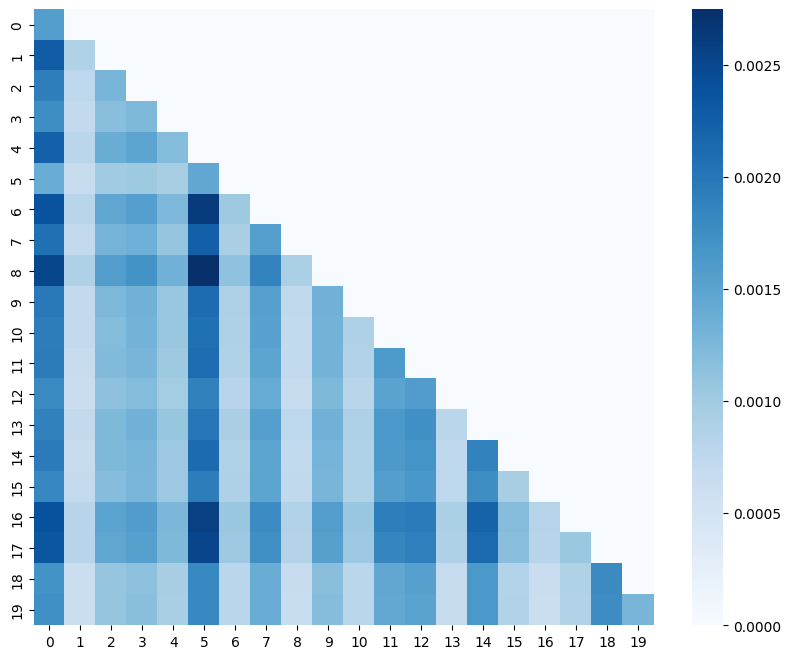

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(10, 8))
sns.heatmap(weight[i, 179:, 179:], cmap="Blues")
plt.show()

### 保存为矢量图eps格式，然后插入latex中不会失真
#### https://blog.csdn.net/weixin_48880917/article/details/123583000

[[0.32105294 0.11590182 0.2013815  0.21641806 0.17413199 0.3359065
  0.14677449 0.2556903  0.1201302  0.21811381 0.14521678 0.2666882
  0.2805627  0.1255784  0.3010267  0.15897174 0.11624333 0.15870202
  0.3262349  0.2372912 ]]


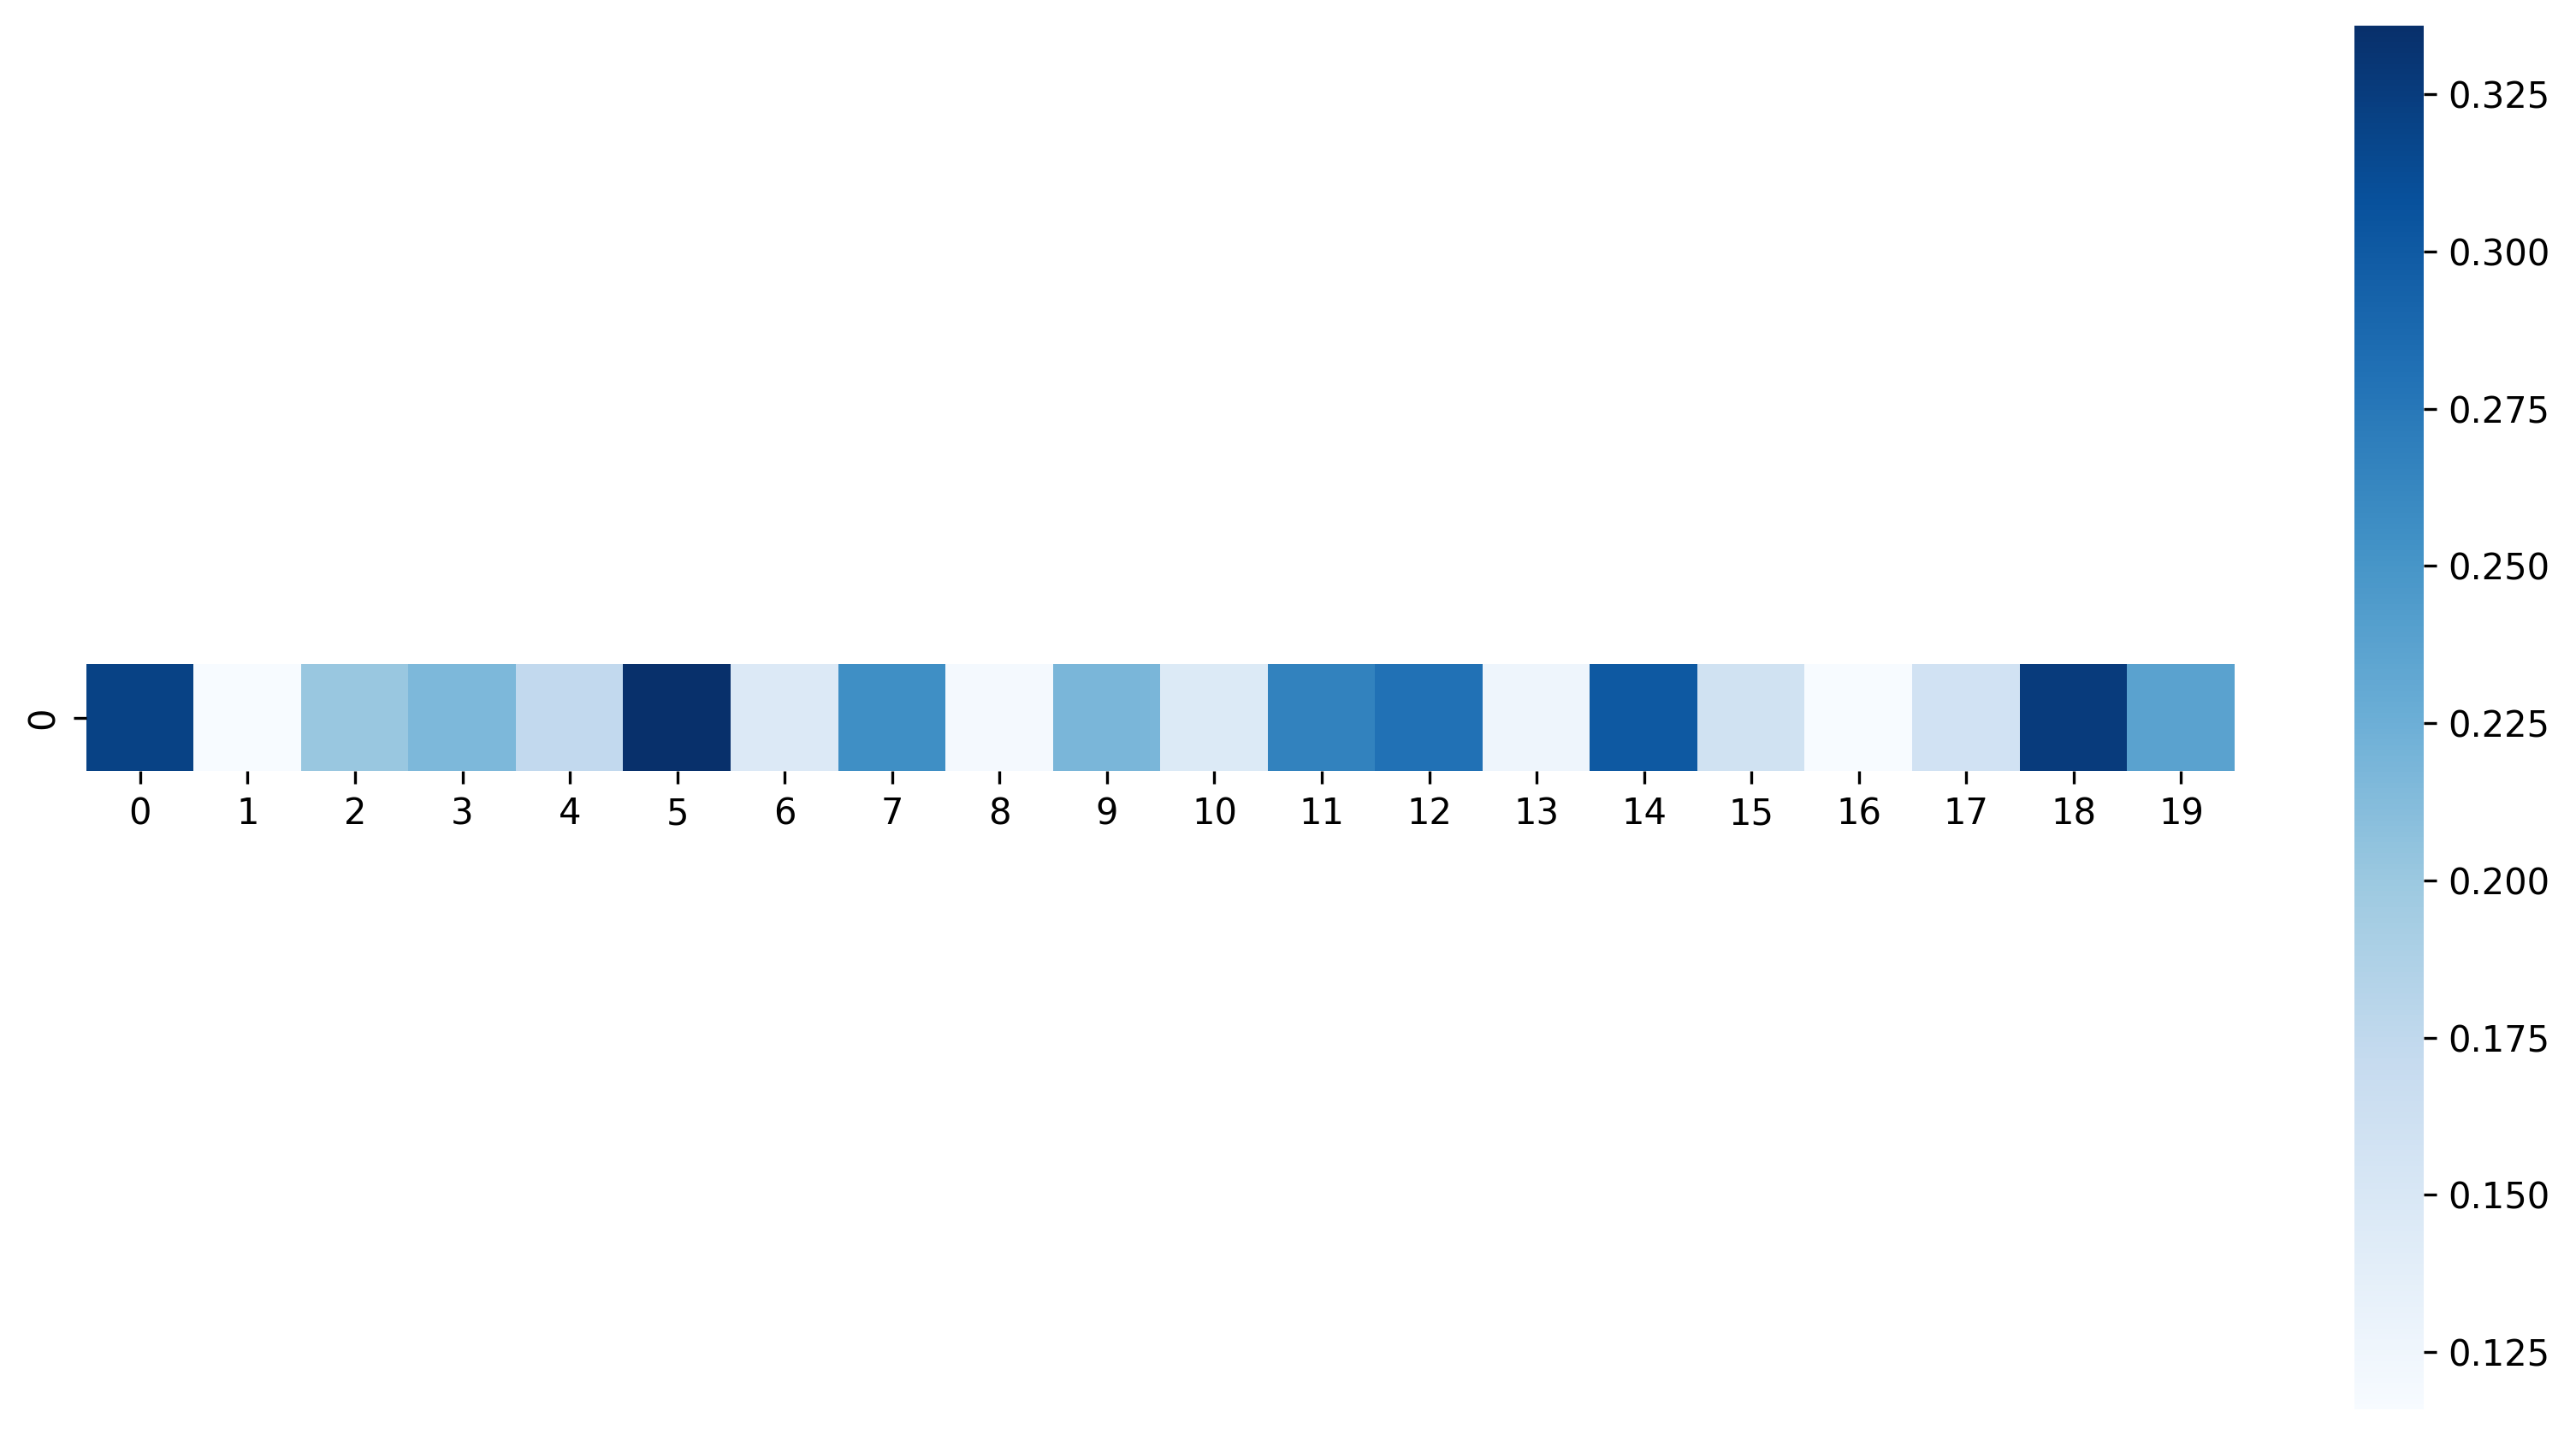

In [ ]:
w1 = weight[i, 179:, 179:][-1]
# print(w1)
fig = plt.figure(figsize=(12, 10), dpi=300)
w2 = w1 / np.linalg.norm(w1)
# print(w2)
w2 = w2.reshape(1, -1)
print(w2)
sns.heatmap(w2, cmap="Blues",cbar=True,square=True, cbar_kws={"shrink": 0.7,"fraction": 0.05})
# 
plt.savefig('/home/czy/KT/1/pictures/fig3_weight.eps', dpi=300)  # eps文件，用于LaTeX
# plt.show()